In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv(r"/Users/tawfeeq/Downloads/DS1_C9_S7_Project_AbsenteeismAtWork_Data.csv", sep = ";")
data

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,11,14,7,3,1,289,36,13,33,264.604,...,0,1,2,1,0,1,90,172,30,8
736,1,11,7,3,1,235,11,14,37,264.604,...,0,3,1,0,0,1,88,172,29,4
737,4,0,0,3,1,118,14,13,40,271.219,...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,271.219,...,0,1,2,1,0,2,100,170,35,0


In [3]:
data.describe()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,...,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,271.490235,...,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,39.058116,...,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205.917000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244.387000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264.249000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,294.217000,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378.884000,...,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


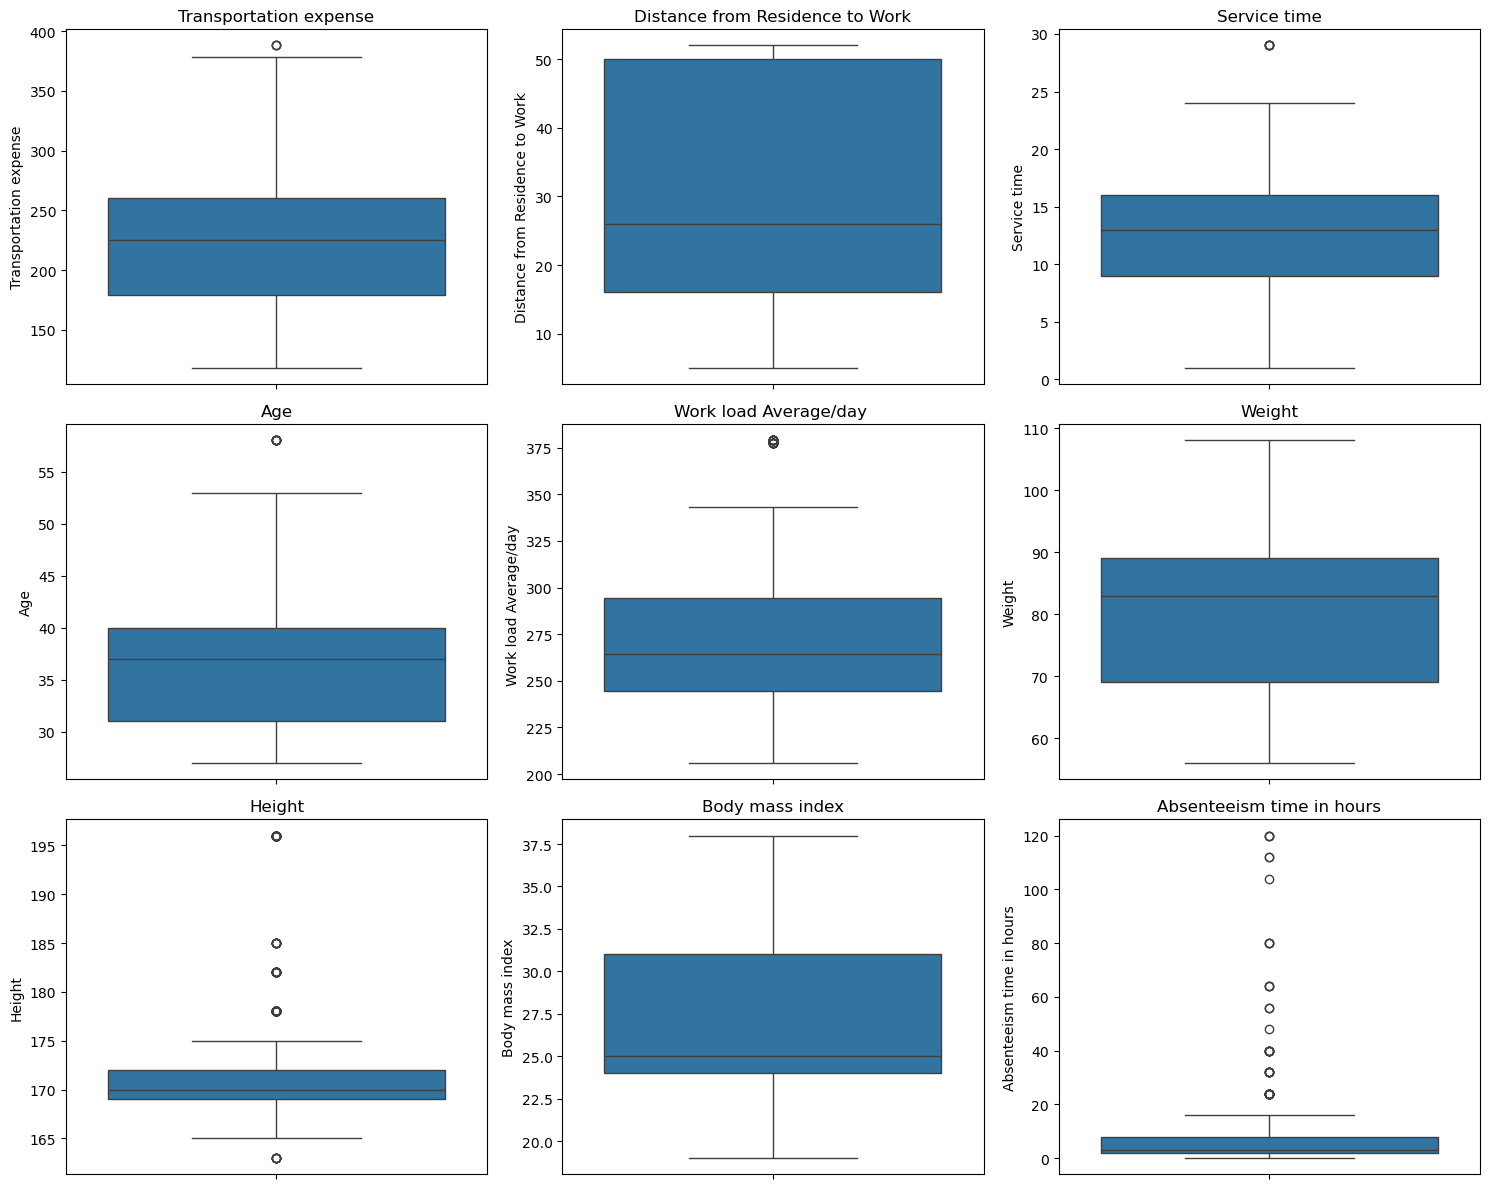

In [4]:
num_cols = ['Transportation expense','Distance from Residence to Work','Service time','Age','Work load Average/day ',
            'Weight','Height','Body mass index','Absenteeism time in hours']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y = data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [5]:
data1 = data.copy()

In [6]:
no_outlier = data1.copy()

def outlier_cleanup(col):
    # Calculate IQR and outlier fences
    q1 = no_outlier[col].quantile(0.25)
    q3 = no_outlier[col].quantile(0.75)
    iqr = q3 - q1
    lf = q1 - (1.5 * iqr) # Lower fence
    uf = q3 + (1.5 * iqr) # upper fence
    # Check column type for proper handling of integer and float types
    col_type = str(no_outlier[col] .dtype)
    # Apply outlier treatment
    if col_type in ["int64", "int32", "int16", "int8", "float16", "float32", "float64"]:
        # For integer columns, round the fence values and cast them to integers
        no_outlier.loc[no_outlier[col] < lf, col] = int(round(lf))
        no_outlier.loc[no_outlier[col] > uf, col] = int(round(uf))
    else:        
        # For float columns, directly assign the fence values
        no_outlier.loc[no_outlier[col] < lf, col ] = lf
        no_outlier.loc[no_outlier[col] > uf, col ] = uf

In [7]:
for col in data1.columns:
    outlier_cleanup(col)

In [8]:
no_outlier       # Data without outliers

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,0,1,1,1,0,0,98,176,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,0,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,11,14,7,3,1,289,36,13,33,264.604,...,0,1,2,1,0,1,90,172,30,8
736,1,11,7,3,1,235,11,14,37,264.604,...,0,1,1,0,0,1,88,172,29,4
737,4,0,0,3,1,118,14,13,40,271.219,...,0,1,1,1,0,2,98,170,34,0
738,8,0,0,4,2,231,35,14,39,271.219,...,0,1,2,1,0,2,100,170,35,0


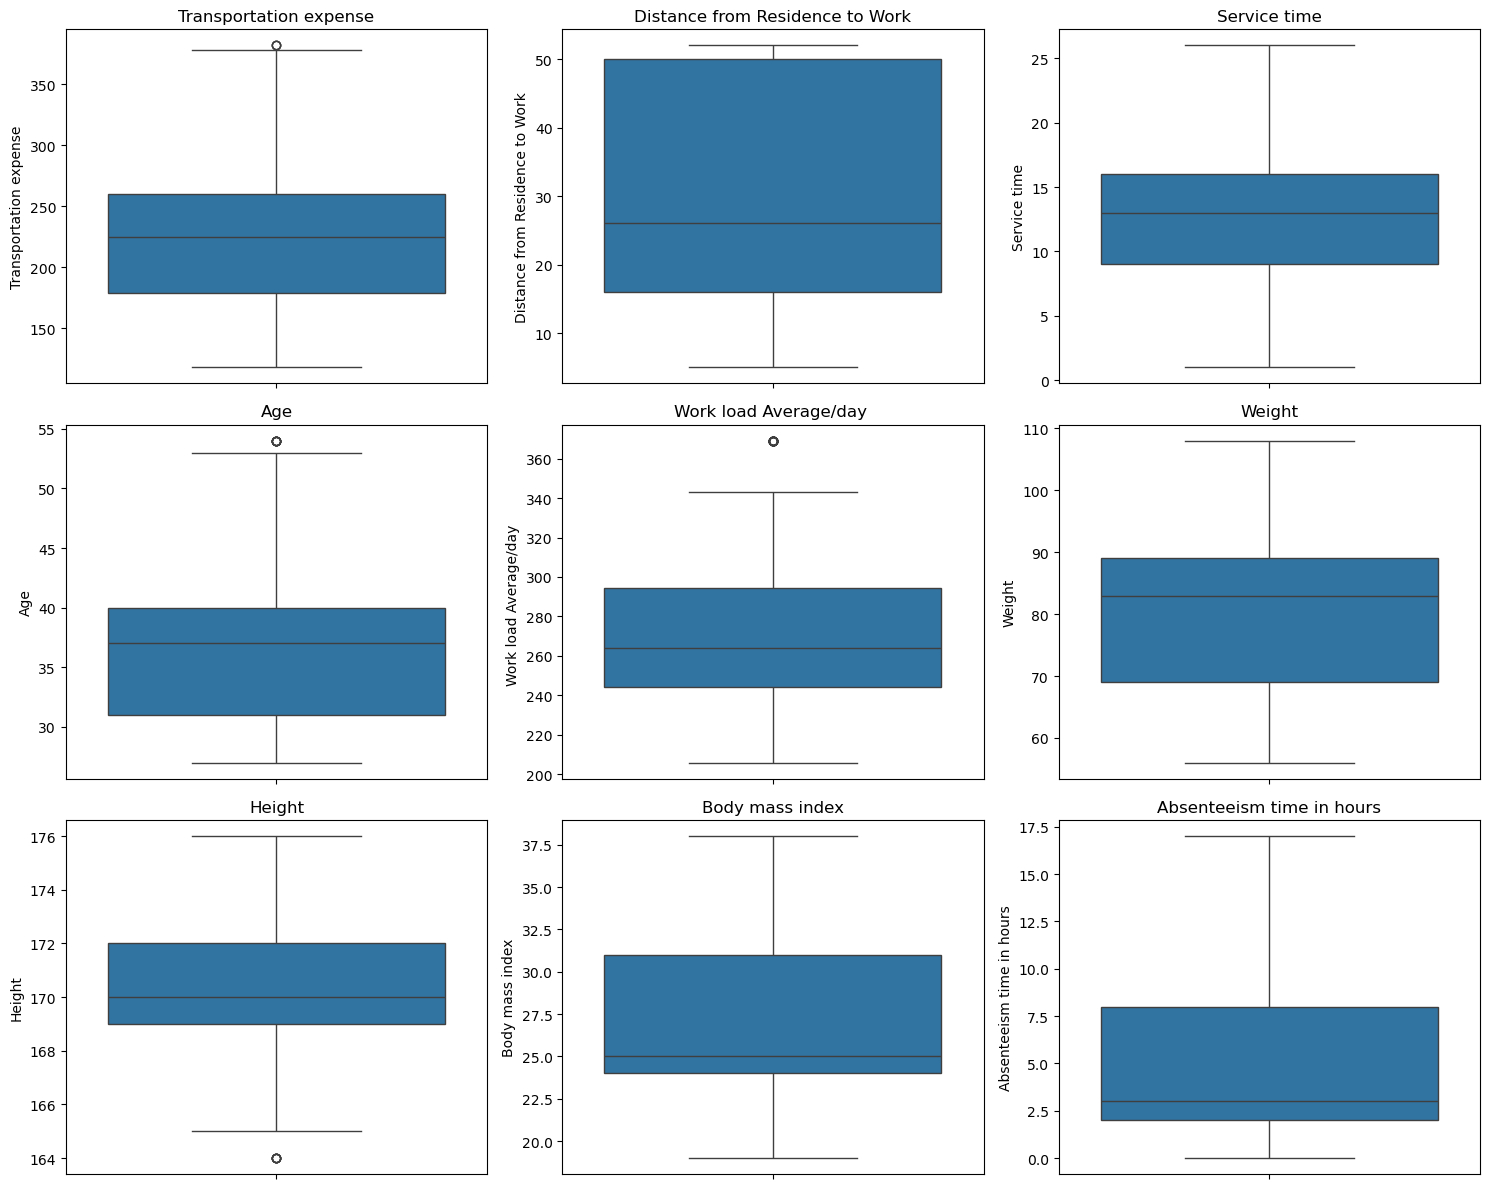

In [9]:
num_cols = ['Transportation expense','Distance from Residence to Work','Service time','Age','Work load Average/day ',
            'Weight','Height','Body mass index','Absenteeism time in hours']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=no_outlier[col])
    plt.title(col)
plt.tight_layout()
plt.show()

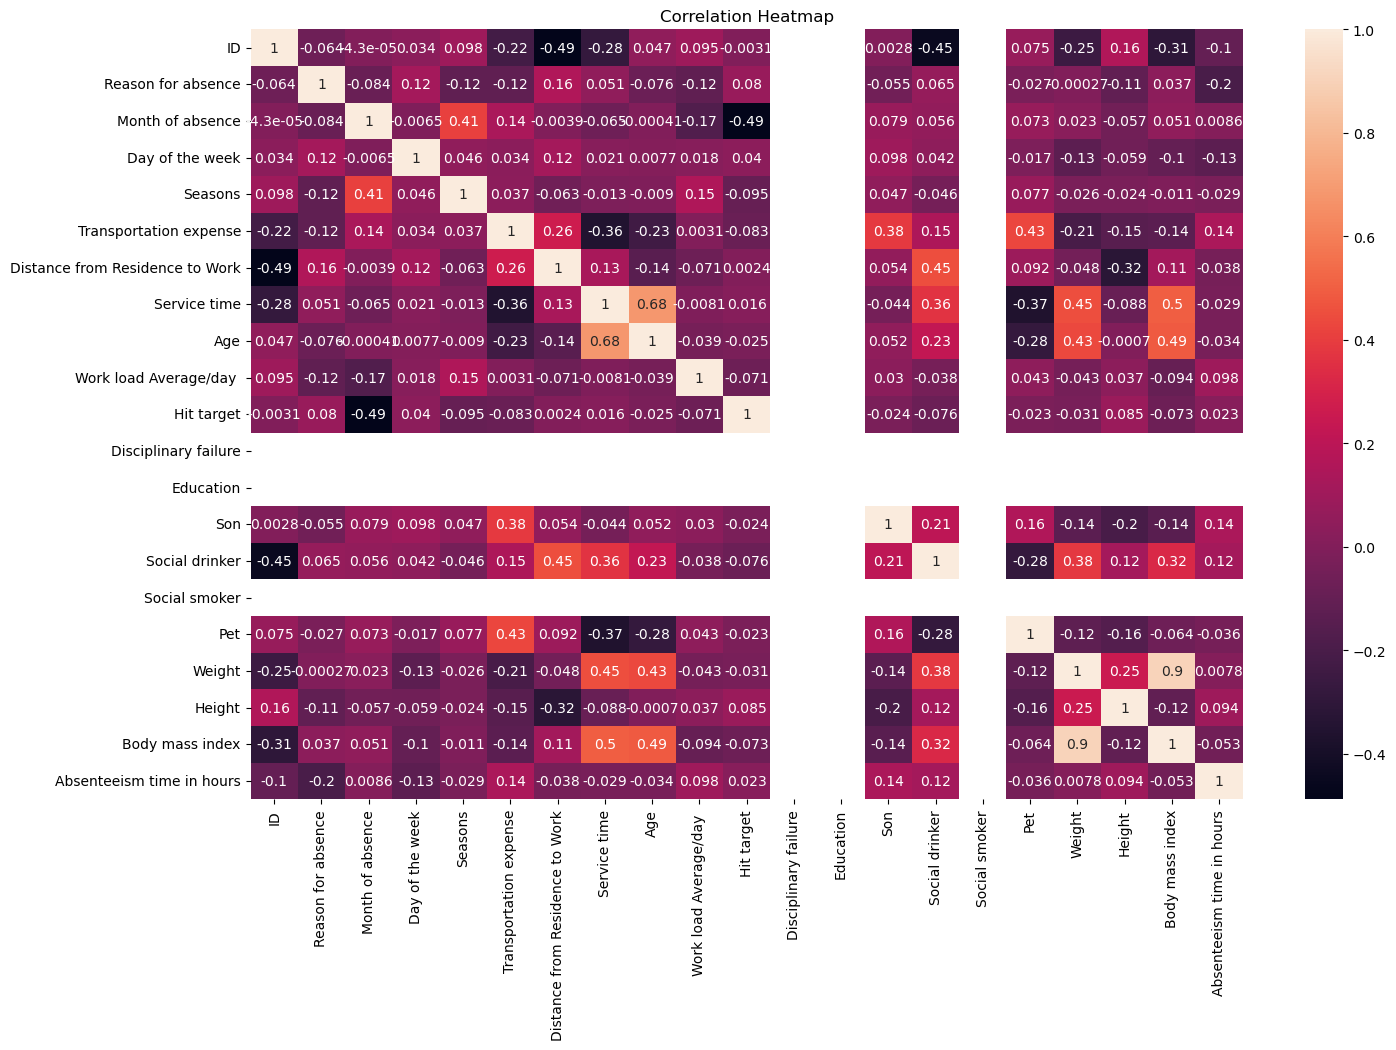

In [10]:
plt.figure(figsize=(16, 10))
sns.heatmap(no_outlier.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
no_outlier.columns

Index(['ID', 'Reason for absence', 'Month of absence', 'Day of the week',
       'Seasons', 'Transportation expense', 'Distance from Residence to Work',
       'Service time', 'Age', 'Work load Average/day ', 'Hit target',
       'Disciplinary failure', 'Education', 'Son', 'Social drinker',
       'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index',
       'Absenteeism time in hours'],
      dtype='object')

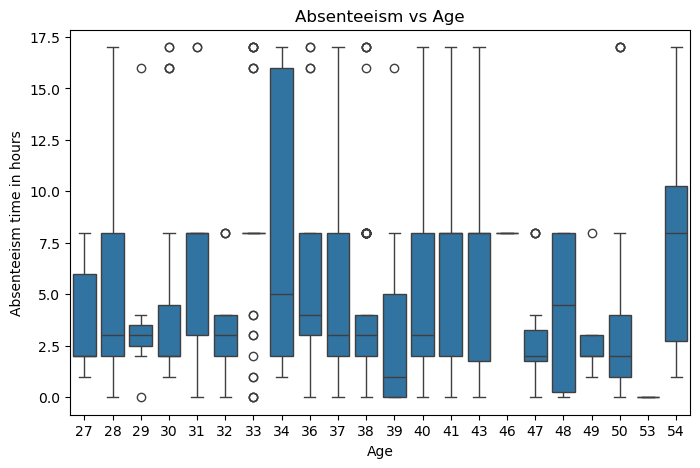

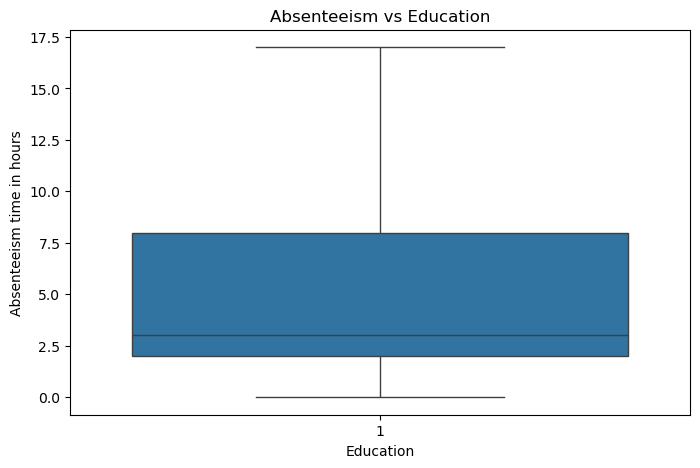

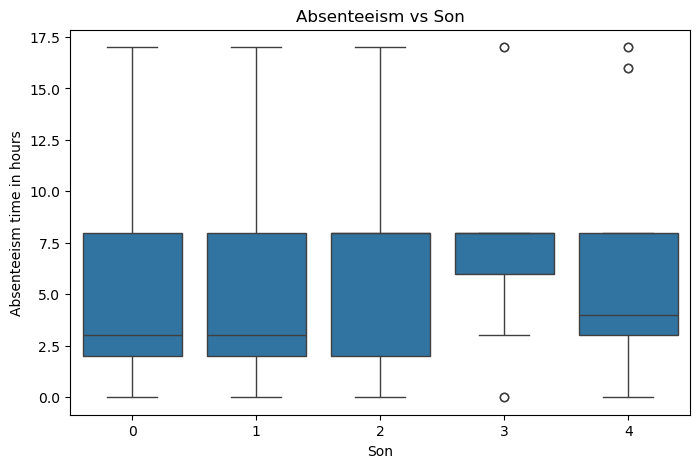

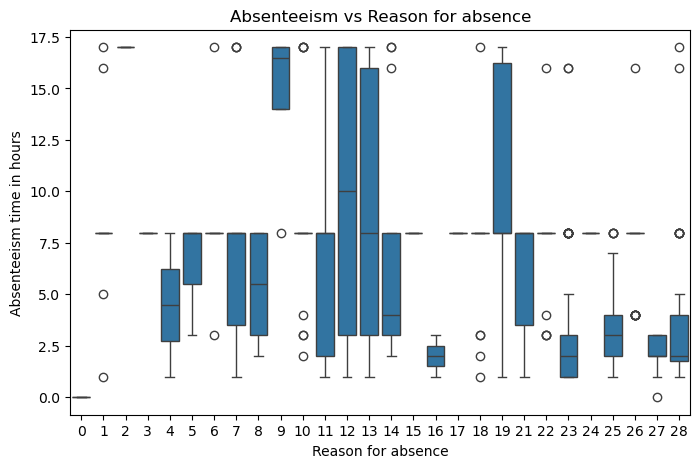

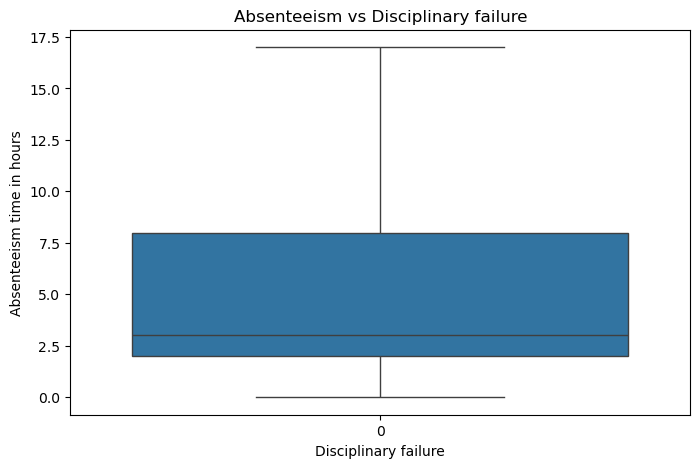

In [12]:
# Absenteeism across different employee demographics in no outlier data
demographics = ["Age", "Education", "Son", "Reason for absence", "Disciplinary failure"]

for i in demographics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x = i, y = "Absenteeism time in hours", data = no_outlier)
    plt.title(f"Absenteeism vs {i}")
    plt.show()

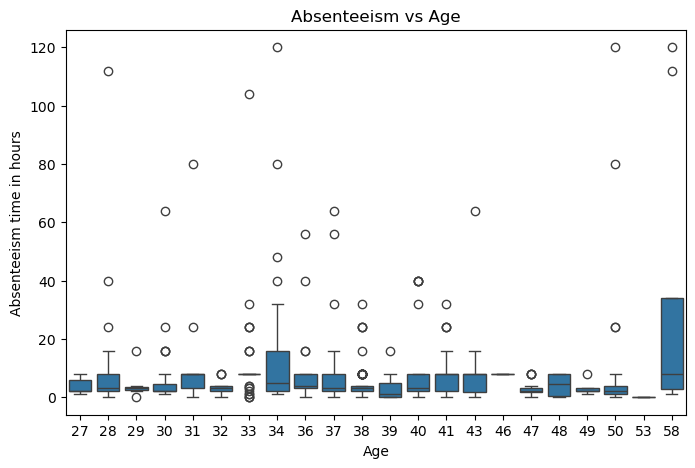

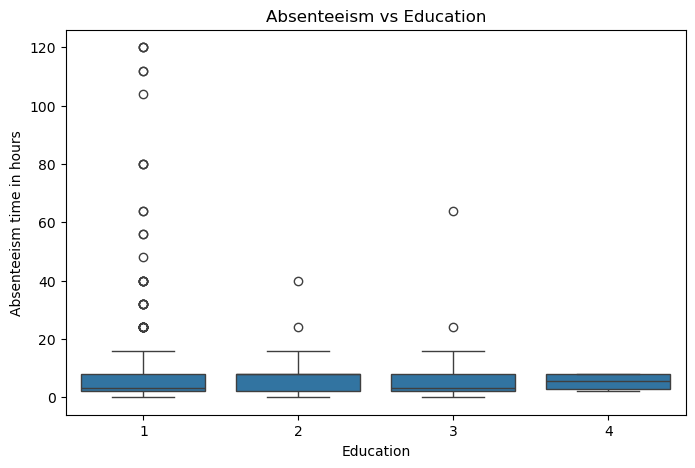

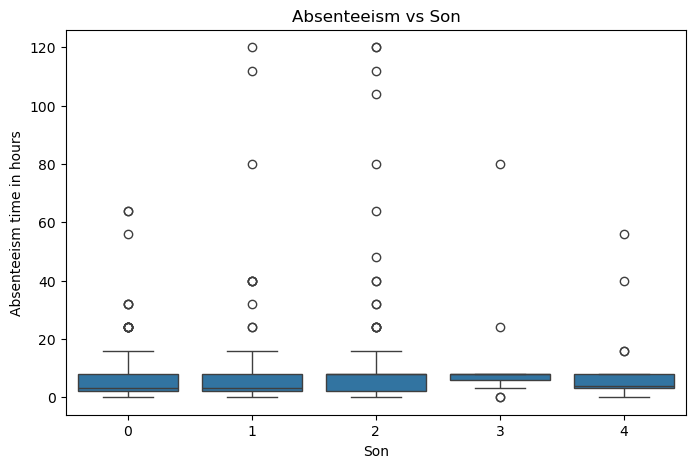

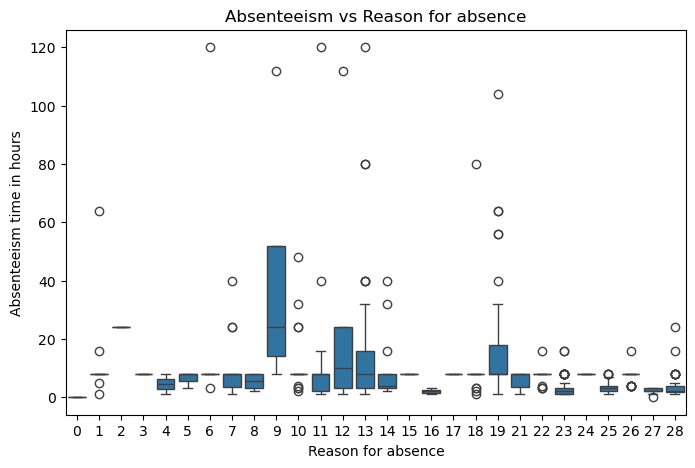

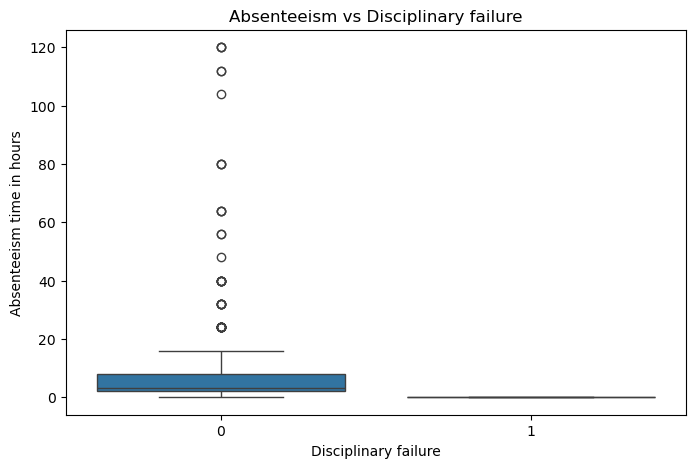

In [13]:
# Absenteeism across different employee demographics when outliers are present
categorical_vars1 = ["Age", "Education", "Son", "Reason for absence", "Disciplinary failure"]

for i in categorical_vars1:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x = i, y = "Absenteeism time in hours", data = data1)
    plt.title(f"Absenteeism vs {i}")
    plt.show()

In [14]:
# Segmenting Employee based on distance from residence to work, adding a column distance category
def distance_category(x):
    if x <= 10:
        return "Near"
    elif x <= 30:
        return "Moderate"
    else:
        return "Far"
no_outlier["Distance Category"] = no_outlier["Distance from Residence to Work"].apply(distance_category)
print(no_outlier.groupby("Distance Category")["Absenteeism time in hours"].mean())

Distance Category
Far         5.093426
Moderate    5.105128
Near        4.475410
Name: Absenteeism time in hours, dtype: float64


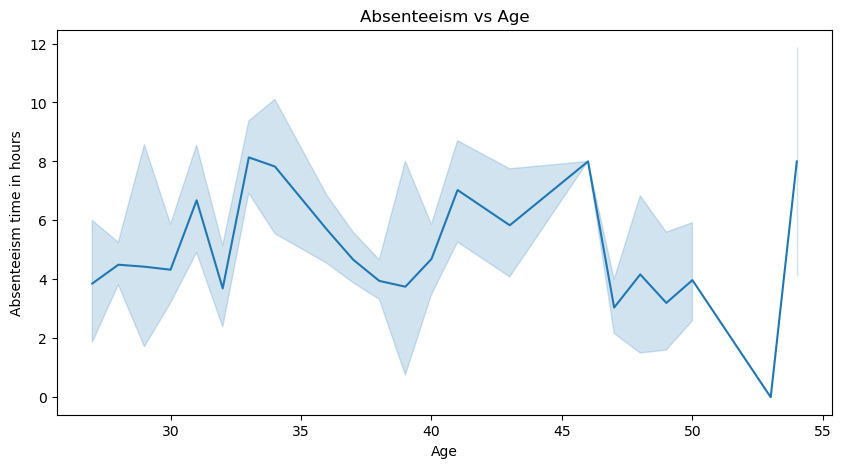

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(x = "Age", y = "Absenteeism time in hours", data = no_outlier)
plt.title("Absenteeism vs Age")
plt.show()

# This shows aroud the ages of 30 - 35, 45 - 50, 50 - 55 are taken more hours when comapred to others

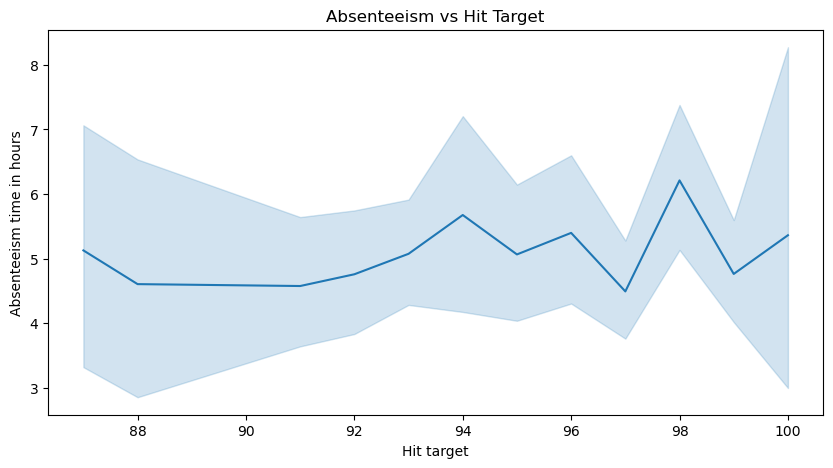

In [17]:
plt.figure(figsize=(10, 5))
sns.lineplot(x = "Hit target", y = "Absenteeism time in hours", data = no_outlier)
plt.title("Absenteeism vs Hit Target")
plt.show()

# Employees with the Hit Target more than 90 tend to have more absenteeism time in hours

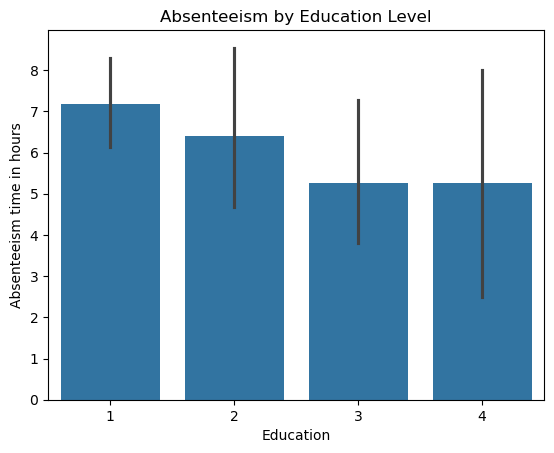

In [19]:
sns.barplot(data = data1, x = "Education" , y = "Absenteeism time in hours")
plt.title("Absenteeism by Education Level")
plt.show()         # outliers present data is used to visualise

# The above graph shows that the Education Level 1 (High School) employees tend to take more hours

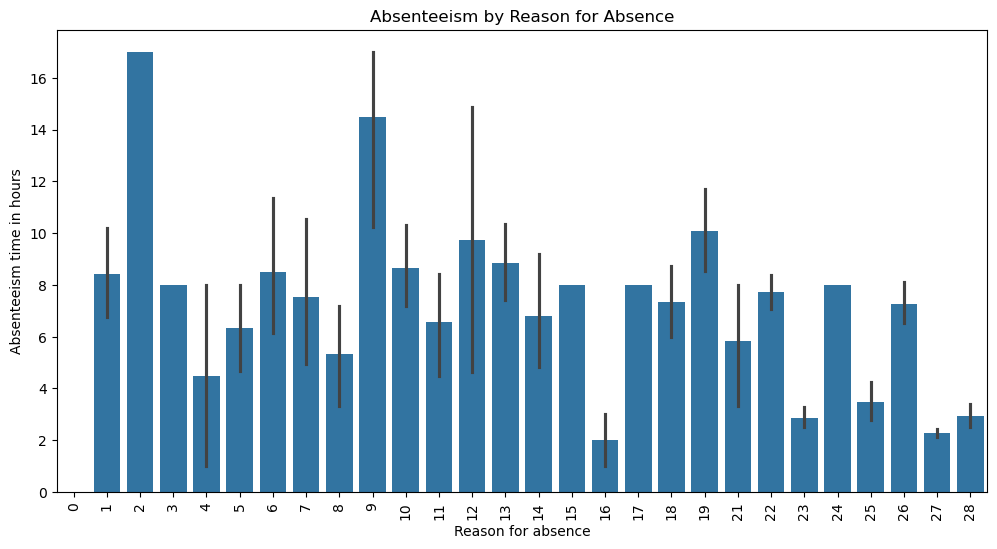

In [21]:
plt.figure(figsize = (12,6))
sns.barplot(data = no_outlier, x = "Reason for absence", y = "Absenteeism time in hours")
plt.xticks(rotation = 90)
plt.title("Absenteeism by Reason for Absence")
plt.show()       # outlier removed data

# When outliers are removed, the most stood out Reason for Highest average absence is 'Neoplasms' which is a tumor

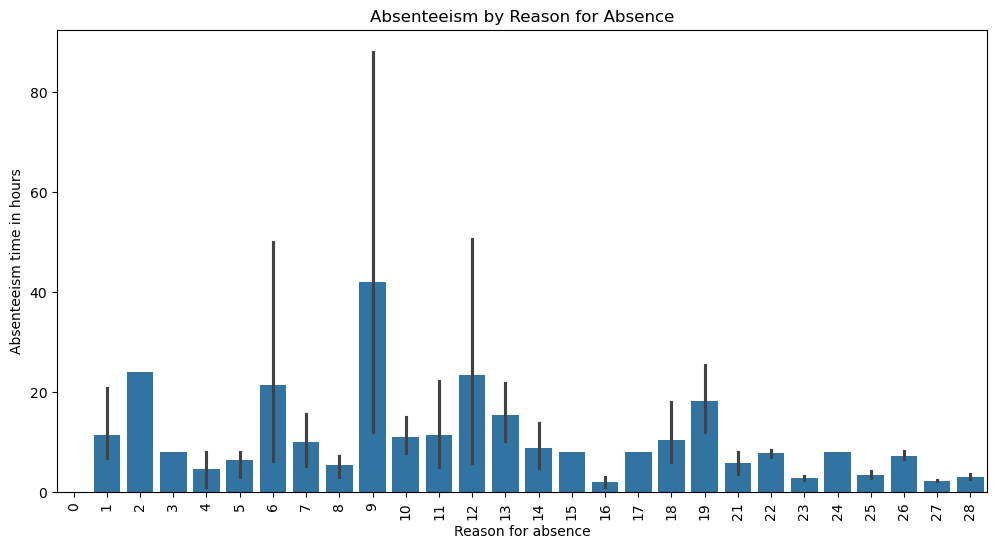

In [23]:
plt.figure(figsize = (12,6))
sns.barplot(data = data1, x = "Reason for absence", y = "Absenteeism time in hours")
plt.xticks(rotation = 90)
plt.title("Absenteeism by Reason for Absence")
plt.show()  # outliers are present

# But when outliers are present the Reason 9 stood out as the highest which was a Disease from the circulatory system, the most of the employees were having stomach related issues

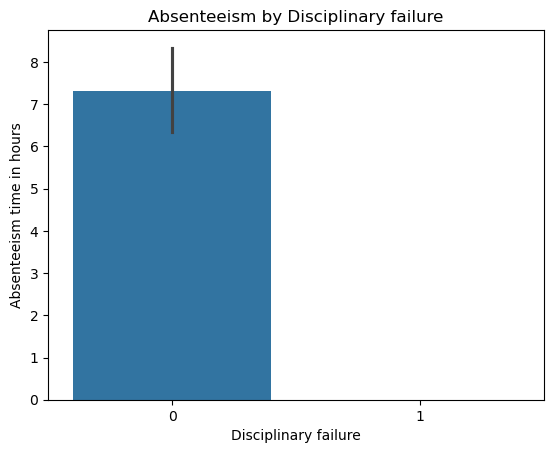

In [25]:
sns.barplot(data = data1, x = "Disciplinary failure", y = "Absenteeism time in hours")
plt.title("Absenteeism by Disciplinary failure")
plt.show()

# None of the employees went through any Disciplinary actions

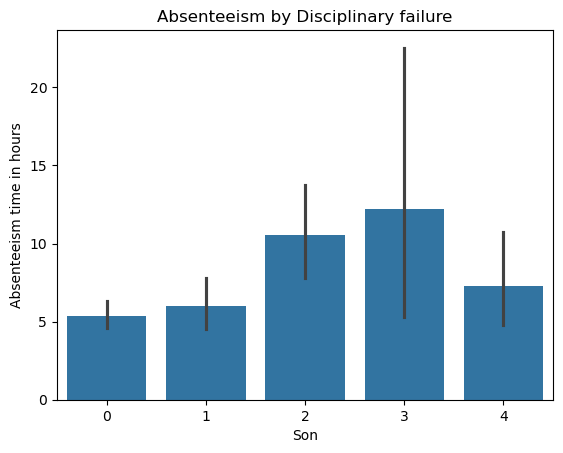

In [27]:
sns.barplot(data = data1, x = "Son", y = "Absenteeism time in hours")
plt.title("Absenteeism by Disciplinary failure")
plt.show()

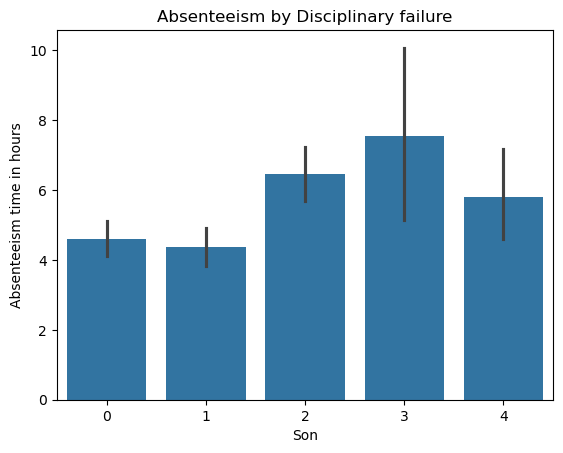

In [28]:
sns.barplot(data = no_outlier, x = "Son", y = "Absenteeism time in hours")
plt.title("Absenteeism by Disciplinary failure")
plt.show()

# Either when the data has no outlier or has outliers, in both scenarios Employees with Three Sons tend to have more absent time hours

# Task 3

Analysing Reasons for Absenteeism

In [32]:
# data with outliers and without outliers shows the same stats 
reason_counts = data1["Reason for absence"].value_counts().sort_values(ascending = False)
print("Most Frequent Reasons for Absence:\n", reason_counts)

Most Frequent Reasons for Absence:
 Reason for absence
23    149
28    112
27     69
13     55
0      43
19     40
22     38
26     33
25     31
11     26
10     25
18     21
14     19
1      16
7      15
6       8
12      8
21      6
8       6
9       4
5       3
16      3
24      3
15      2
4       2
3       1
2       1
17      1
Name: count, dtype: int64


/var/folders/6p/5000n7hx4wb6xn2s7s0xh1tr0000gn/T/ipykernel_10568/1667642959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = reason_counts.index, y = reason_counts.values, palette = 'viridis');


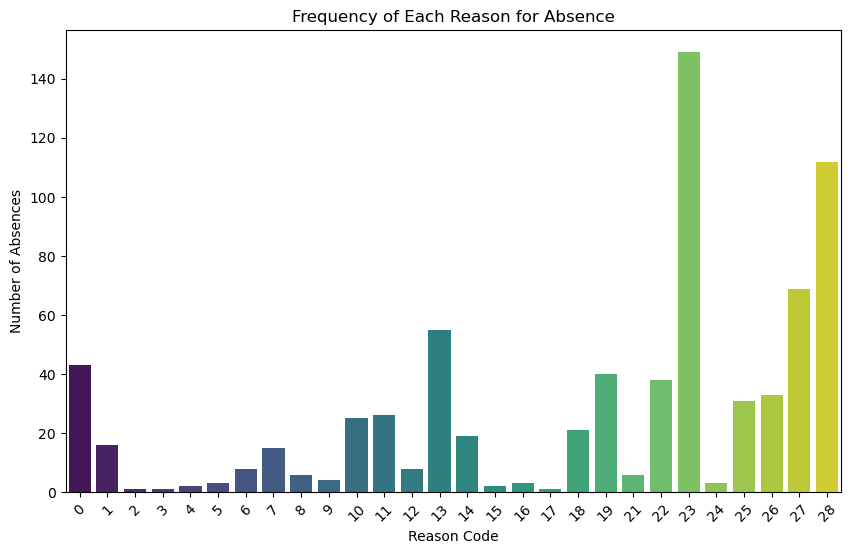

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x = reason_counts.index, y = reason_counts.values, palette = 'viridis');
plt.title("Frequency of Each Reason for Absence")
plt.xlabel("Reason Code")
plt.ylabel("Number of Absences")
plt.xticks(rotation=45)
plt.show()

# From this descriptive analysis, the most frequent reason by count is 23 which is Blood Donation

In [35]:
reasons = {
    0: "Unknown",
    1: "Certain infectious diseases",
    2: "Neoplasms",
    3: "Blood diseases",
    4: "Endocrine diseases",
    5: "Mental disorders",
    6: "Nervous system disorders",
    7: "Eye diseases",
    8: "Ear Diseases",
    9: "Circulatory diseases",
    10: "Respiratory diseases",
    11: "Digestive Diseases",
    12: "Skin diseases",
    13: "Musculoskelatal diseases",
    14: "Genitourinary Diseases",
    15: "Pregnancy, childbrith",
    16: "Prenatal Period",
    17: "Congenital and Chromosomal abnormalities",
    18: "Abnormal Symptoms",
    19: "Injury and poisoning",
    20: "External causes of morbidity",
    21: "Factors influencing health status",
    22: "Medical consultations",
    23: "Blood Donation",
    24: "Laboratory Examination",
    25: "Unjustified Absence",
    26: "Physiotherapy",
    27: "Dental Consulation"
}

In [36]:
data1["Reason Description"] = data1["Reason for absence"].replace(reasons)

In [37]:
data1    # outliers present

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours,Reason Description
0,11,26,7,3,1,289,36,13,33,239.554,...,1,2,1,0,1,90,172,30,4,Physiotherapy
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,0,0,98,178,31,0,Unknown
2,3,23,7,4,1,179,51,18,38,239.554,...,1,0,1,0,0,89,170,31,2,Blood Donation
3,7,7,7,5,1,279,5,14,39,239.554,...,1,2,1,1,0,68,168,24,4,Eye diseases
4,11,23,7,5,1,289,36,13,33,239.554,...,1,2,1,0,1,90,172,30,2,Blood Donation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,11,14,7,3,1,289,36,13,33,264.604,...,1,2,1,0,1,90,172,30,8,Genitourinary Diseases
736,1,11,7,3,1,235,11,14,37,264.604,...,3,1,0,0,1,88,172,29,4,Digestive Diseases
737,4,0,0,3,1,118,14,13,40,271.219,...,1,1,1,0,8,98,170,34,0,Unknown
738,8,0,0,4,2,231,35,14,39,271.219,...,1,2,1,0,2,100,170,35,0,Unknown


In [38]:
no_outlier["Reason Description"] = no_outlier["Reason for absence"].replace(reasons)

In [39]:
no_outlier.columns

Index(['ID', 'Reason for absence', 'Month of absence', 'Day of the week',
       'Seasons', 'Transportation expense', 'Distance from Residence to Work',
       'Service time', 'Age', 'Work load Average/day ', 'Hit target',
       'Disciplinary failure', 'Education', 'Son', 'Social drinker',
       'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index',
       'Absenteeism time in hours', 'Distance Category', 'Reason Description'],
      dtype='object')

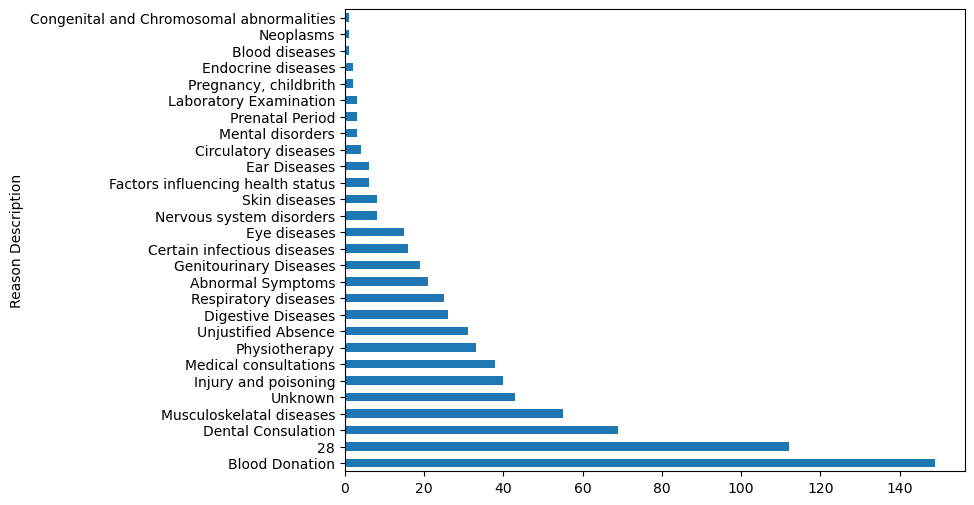

In [40]:
reasons_des = data1["Reason Description"].value_counts()
reasons_des.plot(kind="barh", figsize=(8, 6))
plt.show()

# From the descriptive analysis it is shown that the employees took more absenteeism hours in Donating Blood

# Task 4

Predicting Absenteeism Duration

In [44]:
y = data1["Absenteeism time in hours"]      # Target Column

x = data1[["Reason for absence","Disciplinary failure","Distance from Residence to Work", "Body mass index",
    "Age","Education", "Transportation expense", "Work load Average/day "]]

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.7, random_state=42)

In [46]:
model1 = LinearRegression()
model1.fit(x_train, y_train)

LinearRegression()

In [47]:
y_pred = model1.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R-squared Score:", round(r2, 2))

Mean Squared Error: 177.23
R-squared Score: 0.11


In [48]:
model1.intercept_

23.801803496632054

In [49]:
model1.coef_

array([-4.74900941e-01, -1.77602212e+01, -2.35907022e-02, -3.56546571e-01,
        1.35477018e-01, -2.11579845e+00,  1.43438252e-02, -7.53449839e-03])

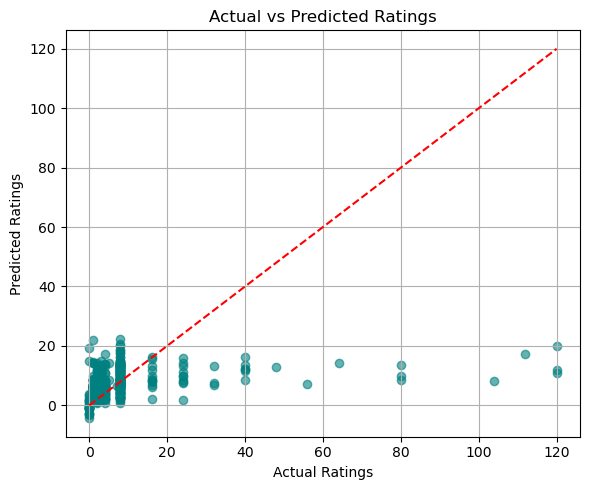

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='teal', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.grid(True)
plt.tight_layout()
plt.show()

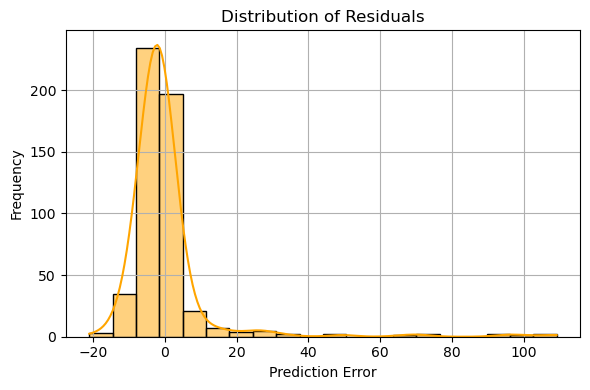

In [51]:
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=20, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
df_res = pd.DataFrame()

In [53]:
df_res["y_predicted"] = pd.DataFrame(y_pred) # Assinging new predicted values to new column in the df
df_res["y_predicted"]

0       4.388827
1       5.460185
2      14.023425
3       1.583104
4       2.044554
         ...    
513     8.637403
514     8.490727
515     5.672739
516     5.807346
517     1.934942
Name: y_predicted, Length: 518, dtype: float64

In [54]:
df_res["y_actual"] = pd.DataFrame(y_test)
df_res["y_actual"]

0      4.0
1      NaN
2      2.0
3      4.0
4      NaN
      ... 
513    2.0
514    1.0
515    2.0
516    8.0
517    3.0
Name: y_actual, Length: 518, dtype: float64

In [55]:
df_res["residual"] = abs(df_res["y_predicted"] - df_res["y_actual"])
df_res

,y_predicted,y_actual,residual
0,4.388827,4.0,0.388827
1,5.460185,NaN,NaN
2,14.023425,2.0,12.023425
3,1.583104,4.0,2.416896
4,2.044554,NaN,NaN
...,...,...,...
513,8.637403,2.0,6.637403
514,8.490727,1.0,7.490727
515,5.672739,2.0,3.672739
516,5.807346,8.0,2.192654


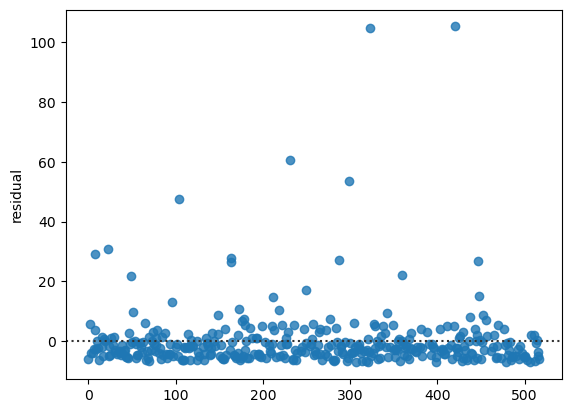

In [56]:
sns.residplot(x=df_res.index, y ="residual" , data = df_res);

# As per the visual Homoscedasticity is followed

# Assumption normality of residuals

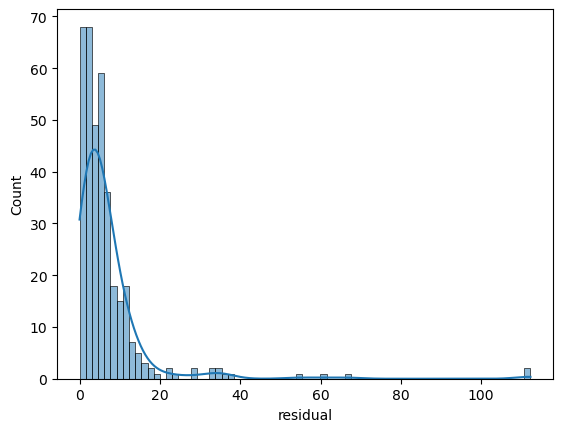

In [59]:
sns.histplot(df_res["residual"],kde = True);

# This assumption fails because errors are not normally distriburted

In [61]:
median_absent = data['Absenteeism time in hours'].median()
data['HighAbsenteeism'] = (data['Absenteeism time in hours'] > median_absent).astype(int)

In [62]:
x3 = data.drop(['ID', 'Absenteeism time in hours', 'HighAbsenteeism'], axis=1)
y3 = data['HighAbsenteeism']

In [112]:
x3 = pd.get_dummies(x3, drop_first=True)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(x3, y3, test_size=0.2, random_state=42)

In [120]:
scaler3 = StandardScaler()
X_train_scaled = scaler3.fit_transform(X_train)
X_test_scaled = scaler3.transform(X_test)

In [124]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

In [128]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [138]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Model Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [140]:
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("KNN", y_test, y_pred_knn)


Logistic Regression Model Performance:
Accuracy: 0.7094594594594594
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.74      0.74        81
           1       0.68      0.67      0.68        67

    accuracy                           0.71       148
   macro avg       0.71      0.71      0.71       148
weighted avg       0.71      0.71      0.71       148

Confusion Matrix:
 [[60 21]
 [22 45]]

KNN Model Performance:
Accuracy: 0.6891891891891891
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.72      0.72        81
           1       0.66      0.66      0.66        67

    accuracy                           0.69       148
   macro avg       0.69      0.69      0.69       148
weighted avg       0.69      0.69      0.69       148

Confusion Matrix:
 [[58 23]
 [23 44]]


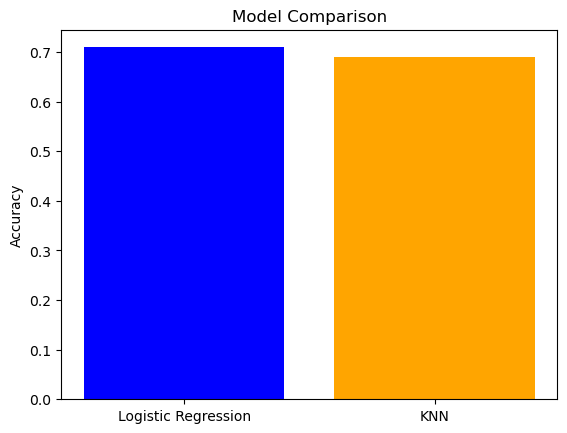

In [142]:
acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)

plt.bar(['Logistic Regression', 'KNN'], [acc_log, acc_knn], color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()

In [144]:
if acc_log > acc_knn:
    print("\n✅ Logistic Regression performs better for identifying high absenteeism employees.")
else:
    print("\n✅ KNN performs better for identifying high absenteeism employees.")


✅ Logistic Regression performs better for identifying high absenteeism employees.


In [146]:
features3 = ['Reason for absence', 'Month of absence', 'Seasons', 'Transportation expense',
            'Distance from Residence to Work', 'Service time', 'Age', 'Work load Average/day ',
            'Hit target', 'Disciplinary failure', 'Education', 'Son', 'Social drinker',
            'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index', 'Absenteeism time in hours']

In [150]:
x4 = data[features3]

In [154]:
scaler4 = StandardScaler()
X_scaled = scaler4.fit_transform(x4)

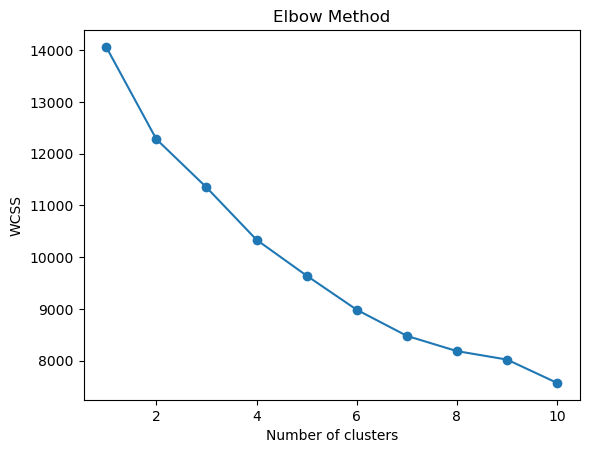

In [158]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [162]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

In [166]:
median_absent = data['Absenteeism time in hours'].median()
data['HighAbsenteeism'] = (data['Absenteeism time in hours'] > median_absent).astype(int)

In [170]:
cluster_summary = data.groupby('Cluster')['HighAbsenteeism'].mean().reset_index()
cluster_summary.rename(columns={'HighAbsenteeism': 'HighAbsenteeism_Rate'}, inplace=True)

/var/folders/6p/5000n7hx4wb6xn2s7s0xh1tr0000gn/T/ipykernel_10568/4175829524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='HighAbsenteeism_Rate', data=cluster_summary, palette='viridis')


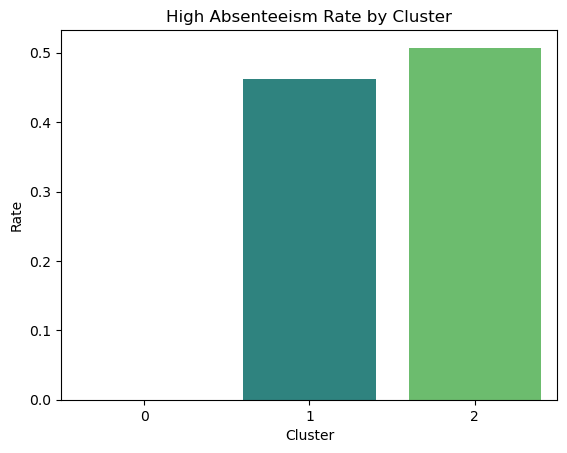

In [172]:
sns.barplot(x='Cluster', y='HighAbsenteeism_Rate', data=cluster_summary, palette='viridis')
plt.title('High Absenteeism Rate by Cluster')
plt.ylabel('Rate')
plt.show()